<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L08-Volatilidad/notebooks/L08_1_SimulacionGARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(10) # para reproducibilidad de simulaciones

In [2]:
# Parámetros para modelo GARCH
alpha0 = 0.1
alpha1 = 0.4
beta1 = 0.2

In [3]:
# Crear la columna w con 10000 muestras de ruido blanco gaussiano
w = np.random.normal(size=10000)

# Crear las columnas E y h únicamente llenas con 0
h = np.zeros(10000)
E = np.zeros(10000)

# Crear el DataFrame
df = pd.DataFrame({'w': w, 'h': h, 'E': E})

# Opcional: mostrar las primeras filas del DataFrame para verificar
print(df.head())

          w    h    E
0  1.331587  0.0  0.0
1  0.715279  0.0  0.0
2 -1.545400  0.0  0.0
3 -0.008384  0.0  0.0
4  0.621336  0.0  0.0


In [4]:
# Iterar a partir de la segunda fila para actualizar 'h' y 'E'
for i in range(1, len(df)):
    # h[i] = alpha_0 + alpha_1 * E[i-1]^2 + beta1 * h[i-1]
    df.loc[i, 'h'] = alpha0 +  alpha1 * (df.loc[i-1, 'E']**2) + beta1 * df.loc[i-1, 'h']

    # E[i] = w[i] * sqrt(h[i])
    df.loc[i, 'E'] = df.loc[i, 'w'] * np.sqrt(df.loc[i, 'h'])

# Mostrar las primeras y últimas filas del DataFrame actualizado para verificar
print("DataFrame (primeras 5 filas):")
print(df.head())
print("\nDataFrame (últimas 5 filas):")
print(df.tail())

DataFrame (primeras 5 filas):
          w         h         E
0  1.331587  0.000000  0.000000
1  0.715279  0.100000  0.226191
2 -1.545400  0.140465 -0.579195
3 -0.008384  0.262280 -0.004294
4  0.621336  0.152463  0.242610

DataFrame (últimas 5 filas):
             w         h         E
9995 -1.073788  0.139988 -0.401757
9996 -0.460671  0.192561 -0.202151
9997  0.647378  0.154858  0.254756
9998  1.250739  0.156932  0.495476
9999  1.162944  0.229585  0.557225


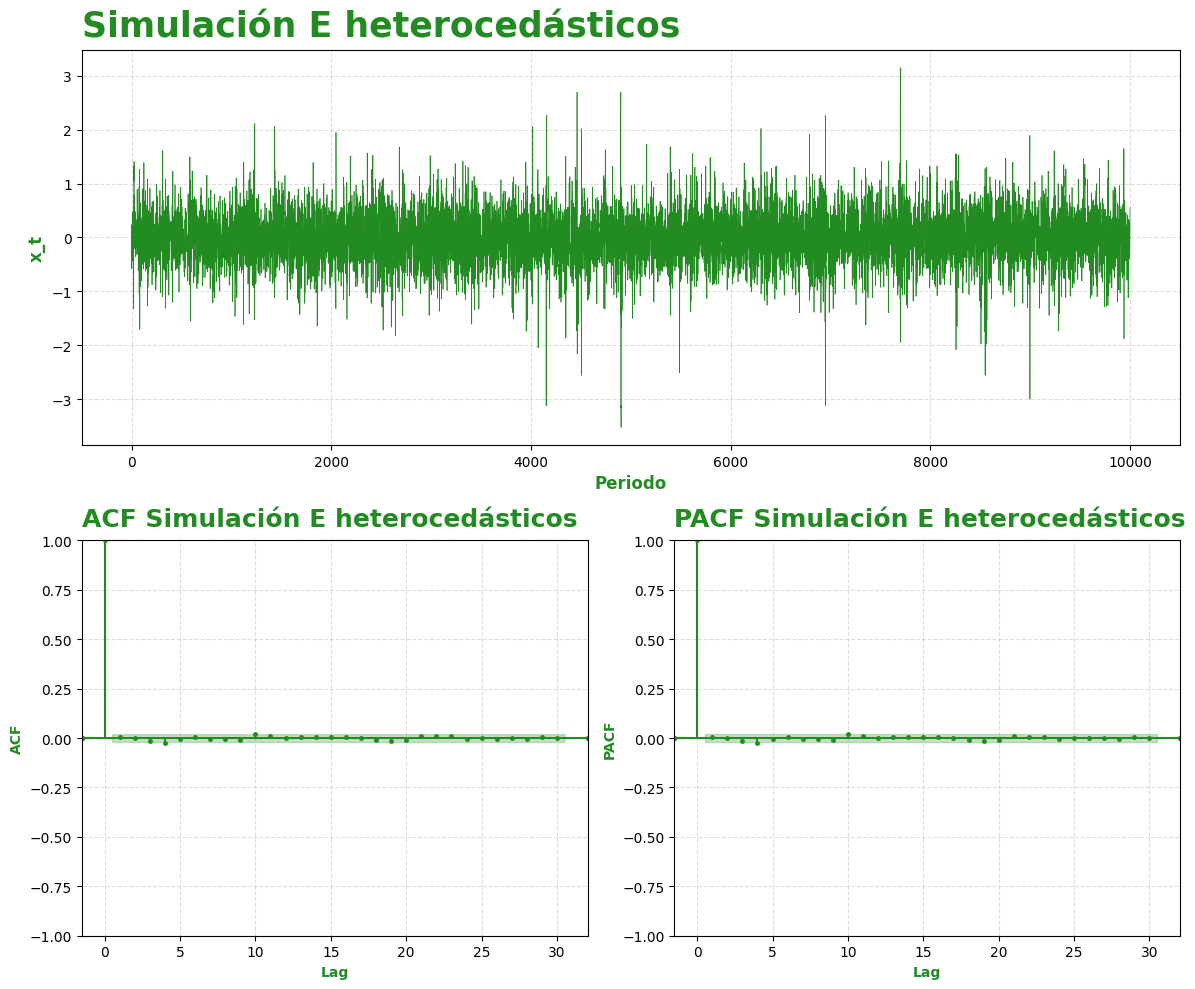

In [8]:
graphColor = 'forestgreen' # Color de los gráficos
columna = 'E'
nombre = 'Simulación E GARCH'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw = 0.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [6]:
df['E_sq'] = df['E']**2

# Mostrar las primeras filas del DataFrame actualizado
print(df.head())

          w         h         E      E_sq
0  1.331587  0.000000  0.000000  0.000000
1  0.715279  0.100000  0.226191  0.051162
2 -1.545400  0.140465 -0.579195  0.335467
3 -0.008384  0.262280 -0.004294  0.000018
4  0.621336  0.152463  0.242610  0.058860


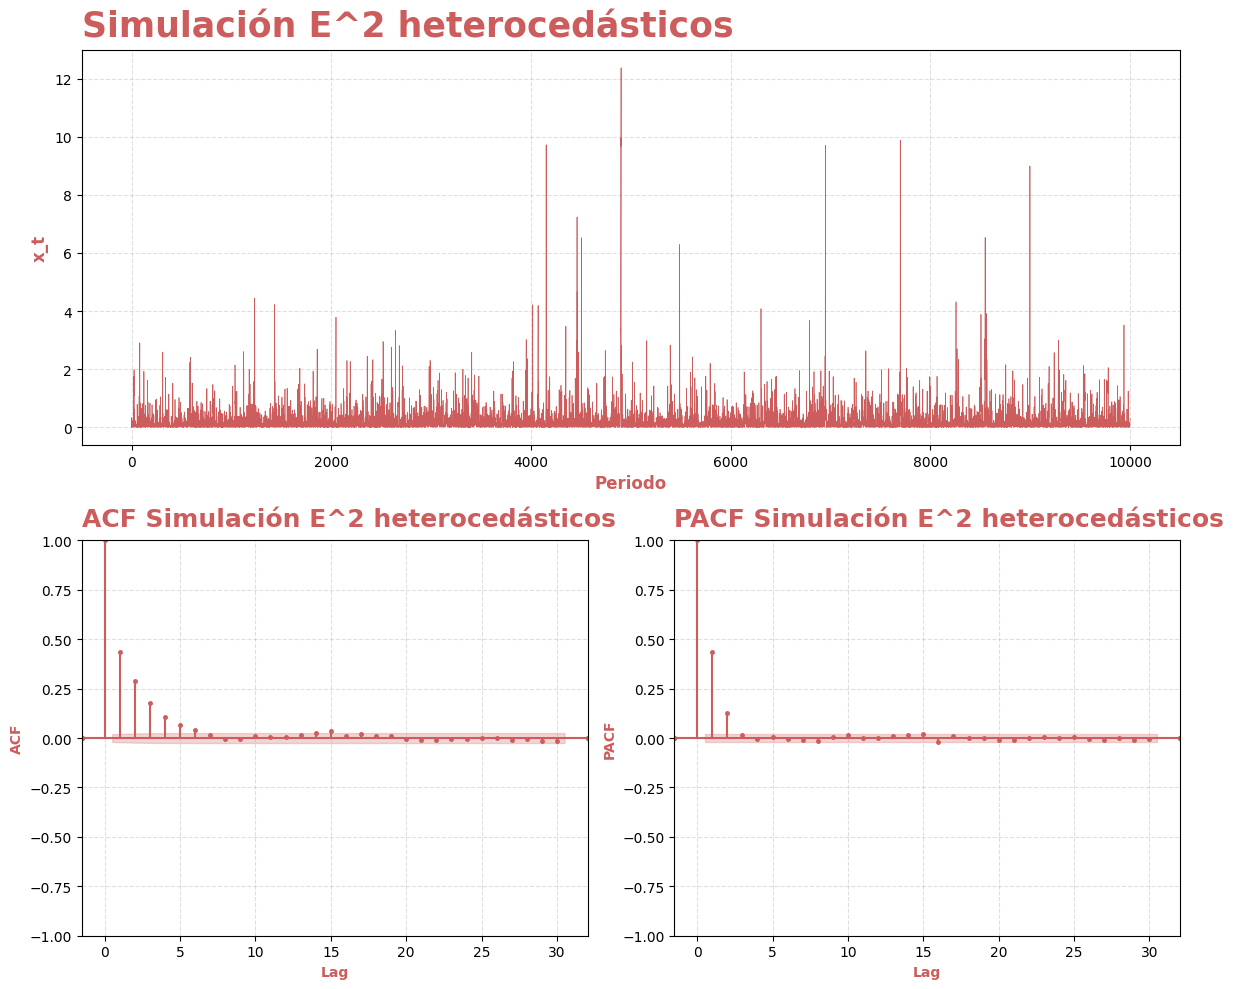

In [9]:
graphColor = 'indianred'
columna = 'E_sq'
nombre = 'Simulación E^2 heterocedásticos'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw = 0.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()